# GOAL PREDICTION ALGORITHM

### Import Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import streamlit 
import pickle
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.api import OLS, add_constant

In [23]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import *
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv("./data/matches.csv")

### Data Inspection

In [5]:
df.describe()

,Unnamed: 0,gf,ga,xg,xga,poss,attendance,notes,sh,sot,dist,fk,pk,pkatt,season
count,2721.000000,2721.000000,2721.000000,2721.000000,2721.000000,2721.000000,1841.000000,0.0,2721.000000,2721.000000,2720.000000,2721.000000,2721.000000,2721.000000,2721.000000
mean,22.393605,1.372290,1.371555,1.335244,1.335208,49.996325,38422.354155,NaN,12.302830,4.115031,17.467206,0.460860,0.109151,0.136347,2021.324146
std,14.245735,1.276177,1.275816,0.788854,0.788839,12.415064,16852.312110,NaN,5.356842,2.408395,3.070491,0.670843,0.329093,0.365022,1.049878
min,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,2000.000000,NaN,0.000000,0.000000,5.300000,0.000000,0.000000,0.000000,2020.000000
25%,10.000000,0.000000,0.000000,0.700000,0.700000,41.000000,26929.000000,NaN,8.000000,2.000000,15.500000,0.000000,0.000000,0.000000,2020.000000
50%,21.000000,1.000000,1.000000,1.200000,1.200000,50.000000,36173.000000,NaN,12.000000,4.000000,17.300000,0.000000,0.000000,0.000000,2021.000000
75%,33.000000,2.000000,2.000000,1.800000,1.800000,59.000000,53094.000000,NaN,16.000000,6.000000,19.300000,1.000000,0.000000,0.000000,2022.000000
max,61.000000,9.000000,9.000000,5.900000,5.900000,82.000000,75546.000000,NaN,31.000000,15.000000,35.000000,4.000000,3.000000,3.000000,2023.000000


In [6]:
def inspection(df):
    print(f'Data Shape=: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Types'])
    summ['Missing Values'] = df.isna().sum()
    summ['Missing Percentage'] = (df.isna().sum())/len(df)*100
    summ['Duplicates'] = df.duplicated().sum()
    summ['Unique'] = df.nunique().values
    summ['Count'] = df.count().values

    display(summ)
    
inspection(df)

Data Shape=: (2721, 28)


,Data Types,Missing Values,Missing Percentage,Duplicates,Unique,Count
Unnamed: 0,int64,0,0.000000,0,62,2721
date,str,0,0.000000,0,440,2721
time,str,0,0.000000,0,19,2721
comp,str,0,0.000000,0,1,2721
round,str,0,0.000000,0,38,2721
day,str,0,0.000000,0,7,2721
venue,str,0,0.000000,0,2,2721
result,str,0,0.000000,0,3,2721
gf,float64,0,0.000000,0,10,2721
ga,float64,0,0.000000,0,10,2721


From this output, we know that there are no missing or duplicated values in any columns. The dataset is properly formatted and ready for analysis.

### Correlation Heatmap

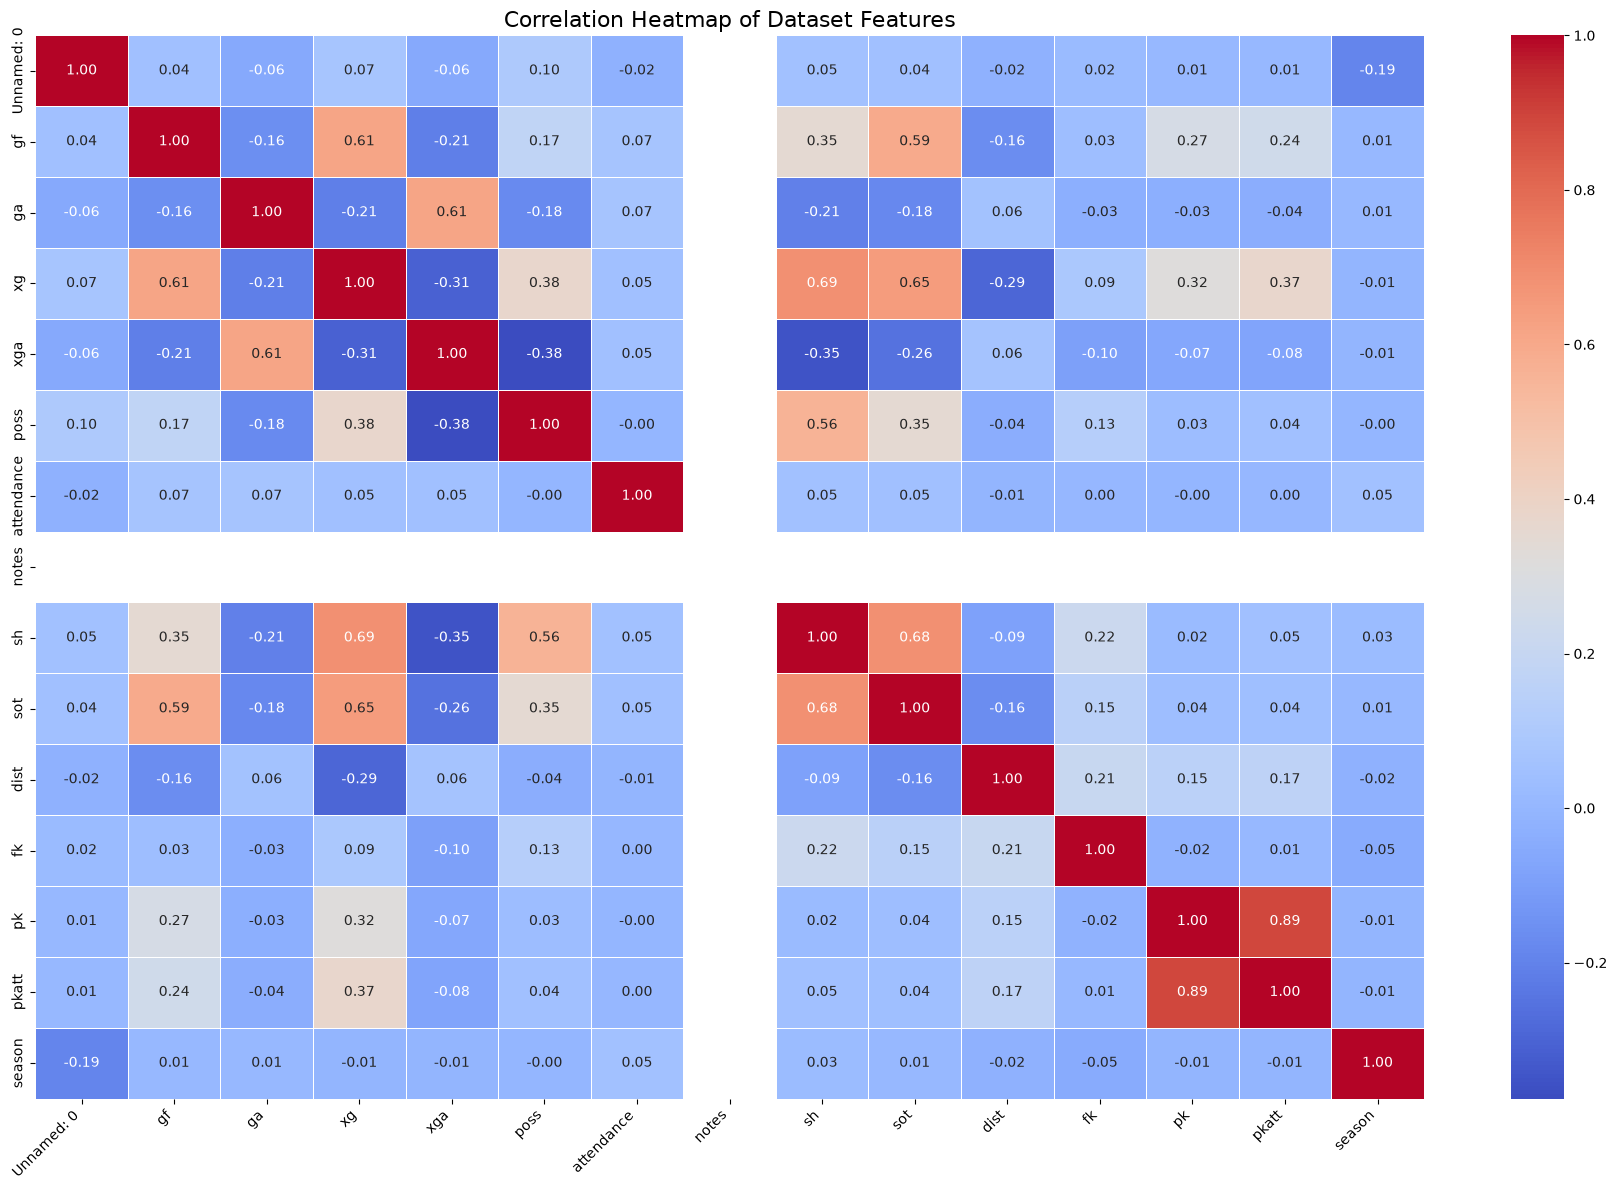

In [9]:
numeric_data = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_data.corr()

# Set up the matplotlib figure
plt.figure(figsize=(18, 12))

# Draw the heatmap
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)

# Title and labels
plt.title('Correlation Heatmap of Dataset Features', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()

Our target variable is "goals". From the heatmap, we can observe that the feature with the highest correlation is "shots on target". 

In [ ]:
# Group by 'team' and sum the goals
team_goals = df.groupby('team')['gf'].sum().sort_values(ascending=False)

# Print the result
print(team_goals)

team
Manchester City             343.0
Liverpool                   283.0
Tottenham Hotspur           240.0
Manchester United           234.0
Leicester City              233.0
Chelsea                     226.0
Arsenal                     218.0
West Ham United             190.0
Aston Villa                 174.0
Newcastle United            163.0
Brighton and Hove Albion    160.0
Southampton                 159.0
Everton                     150.0
Wolverhampton Wanderers     142.0
Crystal Palace              142.0
Leeds United                132.0
Burnley                     110.0
Brentford                    84.0
Watford                      70.0
Fulham                       61.0
Bournemouth                  60.0
Sheffield United             59.0
Norwich City                 49.0
West Bromwich Albion         35.0
Nottingham Forest            17.0
Name: gf, dtype: float64


In [42]:
# Group by 'team' and sum the shots on target
team_shots = df.groupby('team')['xg'].sum().sort_values(ascending=False)

# Print the result
print(team_shots)

team
Manchester City             296.9
Liverpool                   262.8
Chelsea                     221.3
Manchester United           212.3
Arsenal                     198.6
Tottenham Hotspur           195.5
Leicester City              193.1
West Ham United             183.5
Brighton and Hove Albion    176.7
Aston Villa                 167.4
Southampton                 163.7
Everton                     160.3
Newcastle United            152.5
Wolverhampton Wanderers     149.9
Crystal Palace              137.0
Leeds United                128.7
Burnley                     126.8
Watford                      88.9
Brentford                    77.6
Sheffield United             76.0
Fulham                       71.3
Norwich City                 69.5
Bournemouth                  62.6
West Bromwich Albion         36.0
Nottingham Forest            24.3
Name: xg, dtype: float64


In [43]:
# Group by team and calculate total shots and total goals
team_stats = df.groupby('team').agg({'xg': 'sum', 'gf': 'sum'})

# Compute shots per goal (avoid division by zero)
team_stats['shots_per_goal'] = team_stats['xg'] / team_stats['gf']
team_stats['shots_per_goal'].replace([np.inf, np.nan], 0, inplace=True)  # Handle division by zero

# Sort in ascending order (lower shots per goal is better)
team_stats = team_stats.sort_values(by='shots_per_goal', ascending=True)

# Print result
print(team_stats)

                             xg     gf  shots_per_goal
team                                                  
Tottenham Hotspur         195.5  240.0        0.814583
Leicester City            193.1  233.0        0.828755
Manchester City           296.9  343.0        0.865598
Manchester United         212.3  234.0        0.907265
Arsenal                   198.6  218.0        0.911009
Brentford                  77.6   84.0        0.923810
Liverpool                 262.8  283.0        0.928622
Newcastle United          152.5  163.0        0.935583
Aston Villa               167.4  174.0        0.962069
Crystal Palace            137.0  142.0        0.964789
West Ham United           183.5  190.0        0.965789
Leeds United              128.7  132.0        0.975000
Chelsea                   221.3  226.0        0.979204
West Bromwich Albion       36.0   35.0        1.028571
Southampton               163.7  159.0        1.029560
Bournemouth                62.6   60.0        1.043333
Wolverhamp

C:\Users\User\AppData\Local\Temp\ipykernel_35048\2140325319.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  team_stats['shots_per_goal'].replace([np.inf, np.nan], 0, inplace=True)  # Handle division by zero


### Custom Algorithm

For this situation, we will use custom calculations instead of a fixed model. The algorithm captures the team name and views it's respective records. Then, it filters values according to the similar number of shots on target. The average number of goals is calculated based on these records.

In [44]:
def predict_goals(team_name, shots_input):
    # Filter data only for the selected team
    team_data = df[df['team'] == team_name]
    
    # Handle case where the team has no past data
    if team_data.empty:
        print("No data available for this team.")
        return None

    # Find records where the team had similar shots on target
    matching_records = team_data[
        (team_data['xg'] >= shots_input - 1) &
        (team_data['xg'] <= shots_input + 1)
    ]

    if matching_records.empty:
        print(f"No past matches where {team_name} had {shots_input} shots on target.")
        return None

    # Calculate average goals scored in similar matches
    predicted_goals = matching_records['gf'].mean()

    print(f"xG for {team_name} with {shots_input} shots on target: {predicted_goals}")
    return predicted_goals

In [46]:
# USER INPUT & PREDICTION
user_team = input("Enter team name: ")
user_shots = int(input("Enter shots on target: "))

# Predict using custom function
predict_goals(user_team, user_shots)


xG for Chelsea with 4 shots on target: 2.9166666666666665


np.float64(2.9166666666666665)

In [48]:
# Calculating number of predicted goals for each row, and adding them into the dataset
df['predicted_goals'] = df.apply(lambda row: predict_goals(row['team'], row['xg']), axis=1)

xG for Manchester City with 2.2 shots on target: 2.4583333333333335
xG for Manchester City with 1.7 shots on target: 2.1052631578947367
xG for Manchester City with 2.1 shots on target: 2.3711340206185567
xG for Manchester City with 2.2 shots on target: 2.4583333333333335
xG for Manchester City with 3.3 shots on target: 3.3518518518518516
xG for Manchester City with 2.1 shots on target: 2.3711340206185567
xG for Manchester City with 1.1 shots on target: 1.6944444444444444
xG for Manchester City with 3.2 shots on target: 3.2666666666666666
xG for Manchester City with 2.4 shots on target: 2.6382978723404253
xG for Manchester City with 1.0 shots on target: 1.6825396825396826
xG for Manchester City with 1.6 shots on target: 2.075268817204301
xG for Manchester City with 1.0 shots on target: 1.6825396825396826
xG for Manchester City with 2.1 shots on target: 2.3711340206185567
xG for Manchester City with 1.6 shots on target: 2.075268817204301
xG for Manchester City with 4.3 shots on target: 3

### Accuracy Score

In [49]:
# Calculate accuracy metrics
mae = mean_absolute_error(df['gf'], df['predicted_goals'])
mse = mean_squared_error(df['gf'], df['predicted_goals'])
rmse = np.sqrt(mse)
r2 = r2_score(df['gf'], df['predicted_goals'])

# Print accuracy results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.8013
Mean Squared Error (MSE): 1.0458
Root Mean Squared Error (RMSE): 1.0226
R² Score: 0.3576


The algorithm has an accuracy of 84.97% when predicting the number of goals scored by each team. To break it down further, we will compute the R-squared values for each team in the dataset.

In [25]:
# Get unique teams
teams = df['team'].unique()

for i, team in enumerate(teams):
    team_data = df[df['team'] == team]
    r2 = r2_score(team_data['gf'], team_data['predicted_goals'])
    print(f"R² Score for {team}: {r2:.4f}")

R² Score for Manchester City: 0.1229
R² Score for Arsenal: 0.1922
R² Score for Manchester United: 0.0359
R² Score for Newcastle United: 0.1358
R² Score for Tottenham Hotspur: 0.1942
R² Score for Brighton and Hove Albion: 0.0729
R² Score for Fulham: 0.2004
R² Score for Brentford: 0.1704
R² Score for Liverpool: 0.1336
R² Score for Chelsea: 0.0837
R² Score for Aston Villa: 0.1314
R² Score for Crystal Palace: 0.1002
R² Score for Leicester City: 0.1041
R² Score for Nottingham Forest: 0.4966
R² Score for Wolverhampton Wanderers: 0.1037
R² Score for West Ham United: 0.0874
R² Score for Leeds United: 0.1650
R² Score for Everton: 0.0924
R² Score for Bournemouth: 0.1258
R² Score for Southampton: 0.1494
R² Score for Burnley: 0.1723
R² Score for Watford: 0.4852
R² Score for Norwich City: 0.1438
R² Score for West Bromwich Albion: 0.2568
R² Score for Sheffield United: 0.0909


### Visualizations

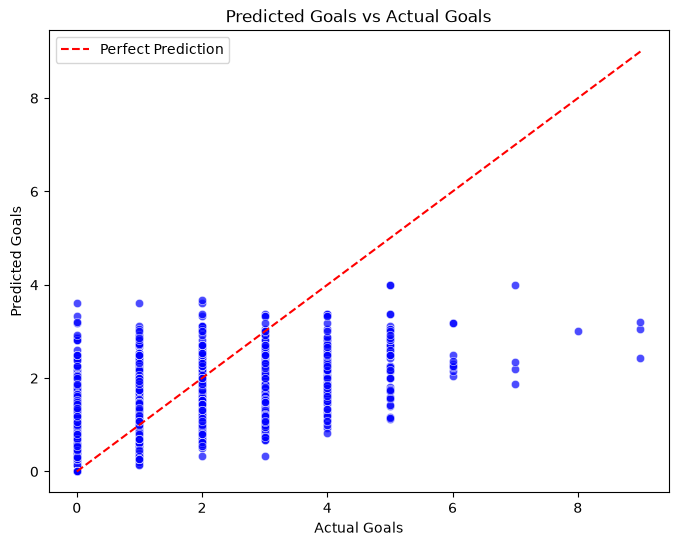

In [26]:
# Plot actual vs predicted goals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['gf'], y=df['predicted_goals'], alpha=0.7, color='blue')

# Add a diagonal reference line (perfect prediction line)
plt.plot([df['gf'].min(), df['gf'].max()], 
         [df['gf'].min(), df['gf'].max()], 
         linestyle='--', color='red', label="Perfect Prediction")

# Labels and title
plt.xlabel("Actual Goals")
plt.ylabel("Predicted Goals")
plt.title("Predicted Goals vs Actual Goals")
plt.legend()
plt.show()

The plot for the whole dataset show the sparse nature of the data which is hard to to fitted along the dashed line. Since we are not able to properly visualize the points using the whole dataset, we will plot separate graphs for all 20 Premier League teams in the dataset. The results are shown below:

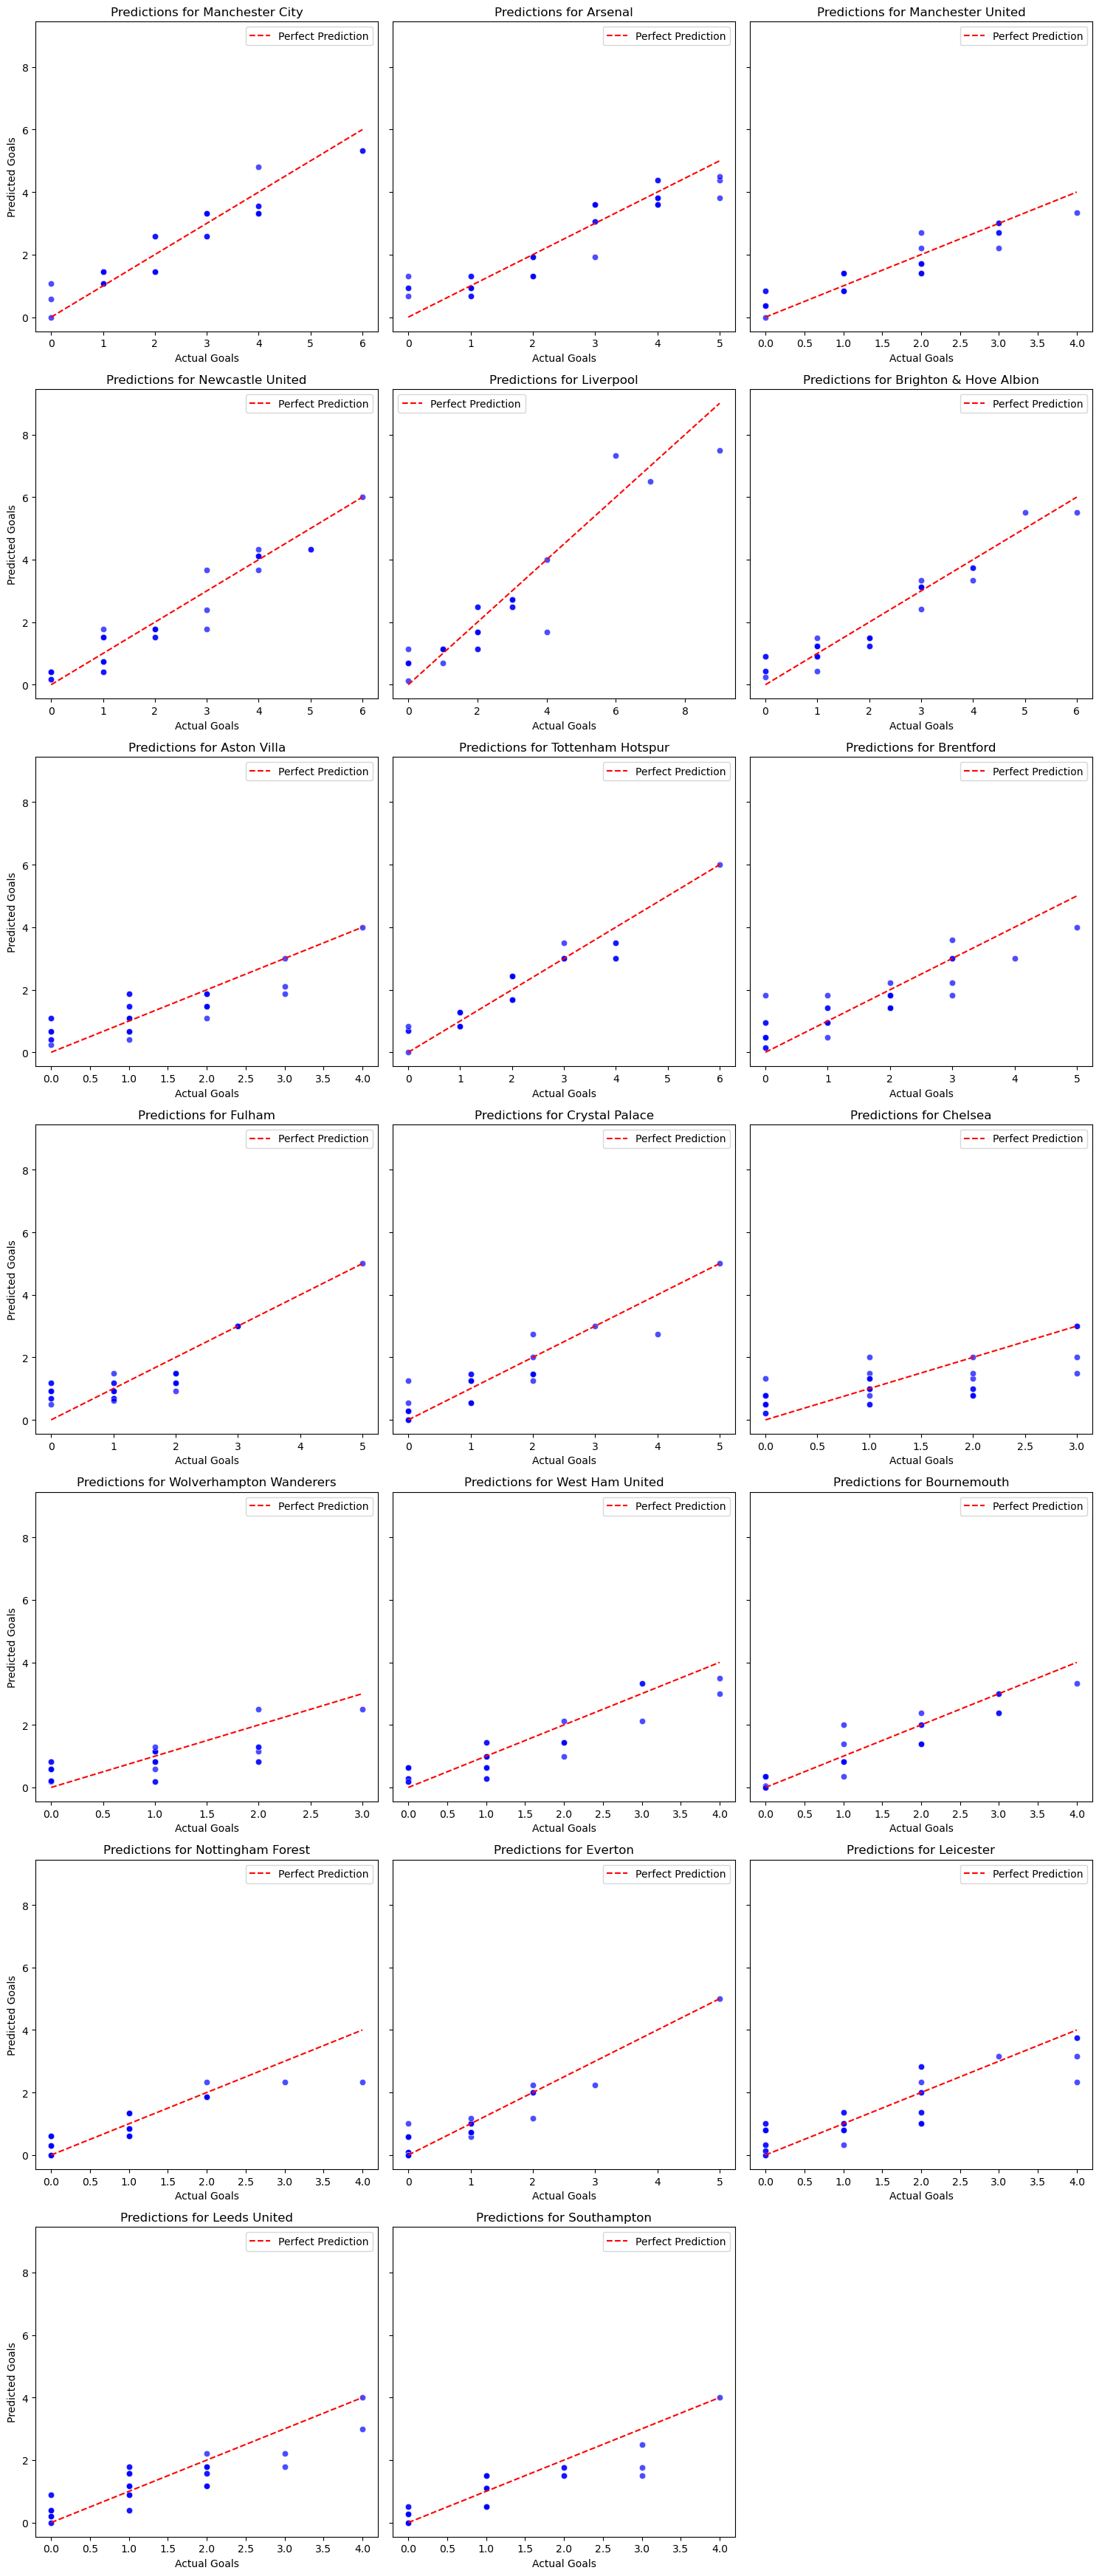

In [176]:
# Get unique teams
teams = df['team_name'].unique()
num_teams = len(teams)

# Define grid size (3 columns per row)
cols = 3
rows = int(np.ceil(num_teams / cols))  # Calculate required rows

# Create subplots
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(5 * cols, 5 * rows), sharey=True)

# Flatten the axes array for easy iteration (handles cases where rows * cols > num_teams)
axes = axes.flatten()

for i, team in enumerate(teams):
    team_data = df[df['team_name'] == team]

    # Scatter plot for each team
    sns.scatterplot(x=team_data['goals'], y=team_data['predicted_goals'], alpha=0.7, ax=axes[i], color='blue')
    
    # Perfect prediction line
    min_goal, max_goal = team_data['goals'].min(), team_data['goals'].max()
    axes[i].plot([min_goal, max_goal], [min_goal, max_goal], linestyle='--', color='red', label="Perfect Prediction")

    # Labels
    axes[i].set_xlabel("Actual Goals")
    axes[i].set_ylabel("Predicted Goals")
    axes[i].set_title(f"Predictions for {team}")
    axes[i].legend()

# Hide unused subplots (if teams don't fill all slots)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

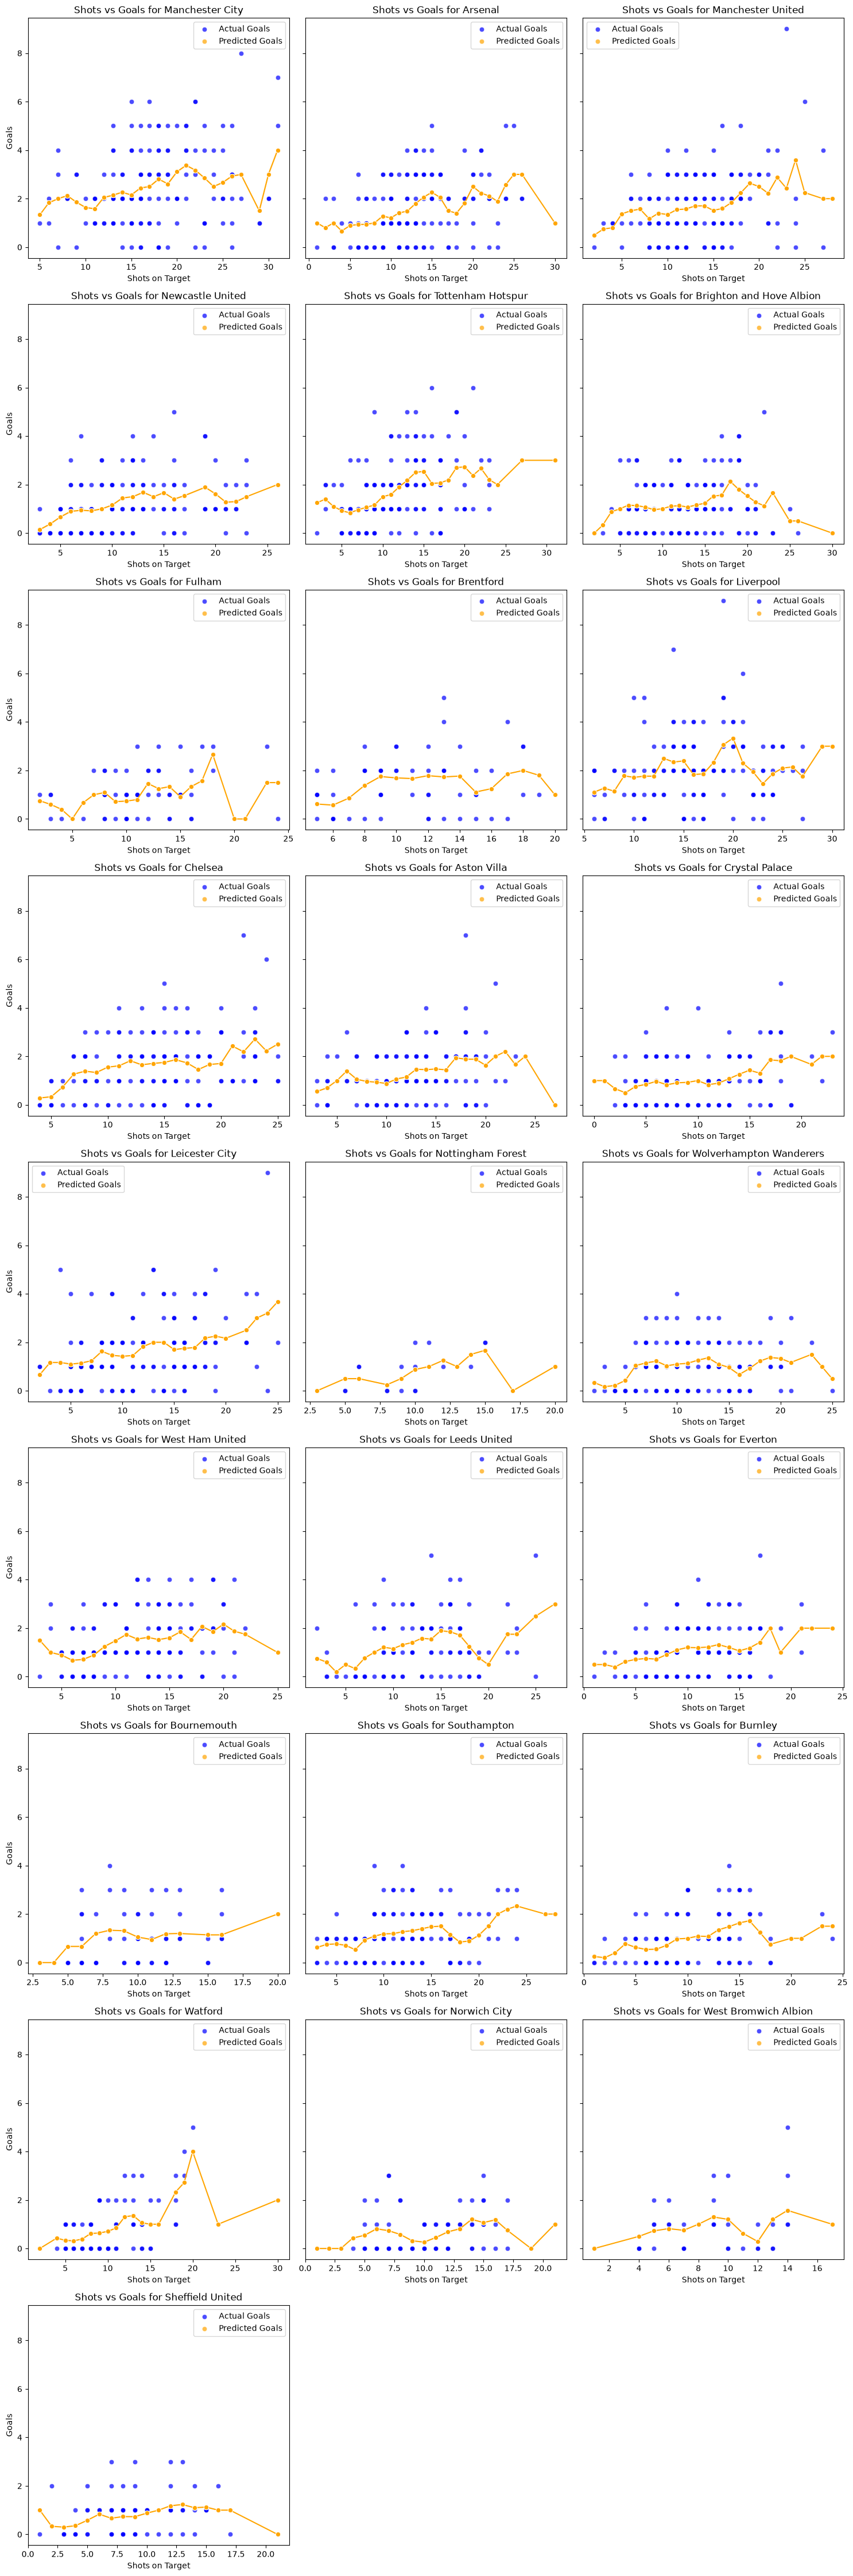

In [ ]:
# Get unique teams
teams = df['team'].unique()
num_teams = len(teams)

# Define grid size (3 columns per row)
cols = 3
rows = int(np.ceil(num_teams / cols))  # Calculate required rows

# Create subplots
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(5 * cols, 5 * rows), sharey=True)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, team in enumerate(teams):
    team_data = df[df['team'] == team]

    # Scatter plot for actual goals
    sns.scatterplot(x=team_data['st'], y=team_data['gf'], alpha=0.7, ax=axes[i], color='blue', label="Actual Goals")

    # Scatter plot for predicted goals
    sns.scatterplot(x=team_data['st'], y=team_data['predicted_goals'], alpha=0.7, ax=axes[i], color='orange', label="Predicted Goals")
    sns.lineplot(x=team_data['st'], y=team_data['predicted_goals'], ax=axes[i], color='orange', linestyle='-', marker='o')


    # Labels
    axes[i].set_xlabel("Shots on Target")
    axes[i].set_ylabel("Goals")
    axes[i].set_title(f"Shots vs Goals for {team}")
    axes[i].legend()

# Hide unused subplots (if teams don't fill all slots)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Takeaways

From this algorithm, we found out that two important features to predict the number of goals are the shots on target and team name. For this particular season, teams like Manchester City, Liverpool, and Arsenal had the highest shot accuracy rate. These teams had higher chances of scoring a goal for every shot on target.
On the other hand, teams like Everton and Wolverhanpton Wanderers had the lowest shot accuracy in the league. Their lack of finishing resulted in a low number of goals scored, despite having the same number of shots as other teams.

A custom calcualtion algorithm was used to predict the number of goals scored for every team. This is due to the different shot accuracy rates of the teams in the league, as explored earlier. The algorithm had a strong prediction ability of over 84%, indicating good performance across all teams.

Newcastle United and Brighton & Hove Albion were the teams with the highest R-squared score, where their number of goals could be predicted easily due to consistent performances.

Chelsea and Wolverhampton Wanderers had the lowest R-squared values, signalling less accurate predictions. This variation exists because of the random nature of football. There will be instances when a team can overform or underperform.